# Chargement des données d’images

Jusqu’à présent, nous avons travaillé avec des ensembles de données assez artificiels, peu représentatifs des projets réels.  
Dans la pratique, vous serez souvent amené à manipuler des **images de grande taille**, comme celles issues d’appareils photo ou de téléphones portables.  
Dans ce notebook, nous verrons comment **charger des images** et les utiliser pour **entraîner des réseaux de neurones**.

Nous utiliserons un [jeu de données de photos de chats et de chiens](https://www.kaggle.com/c/dogs-vs-cats) disponible sur **Kaggle**.  
Voici quelques exemples d’images :



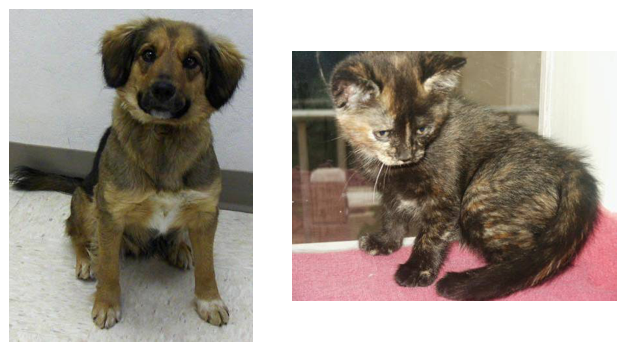

Nous emploierons ce jeu de données pour entraîner un réseau de neurones capable de **distinguer les chats des chiens**.  
Aujourd’hui, cela peut sembler banal, mais il y a encore quelques années, c’était un véritable **défi pour les systèmes de vision par ordinateur**.

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms



La façon la plus simple de charger des images est d’utiliser `datasets.ImageFolder` de la bibliothèque **torchvision** ([documentation](http://pytorch.org/docs/master/torchvision/datasets.html#imagefolder)).  
En général, vous utiliserez `ImageFolder` comme ceci :

```python
dataset = datasets.ImageFolder('path/to/data', transform=transform)
````

où `'path/to/data'` est le chemin d’accès au répertoire contenant les données, et `transform` est une **séquence d’opérations de prétraitement** définies à l’aide du module [`transforms`](http://pytorch.org/docs/master/torchvision/transforms.html) de `torchvision`.

`ImageFolder` s’attend à une structure de répertoires comme celle-ci :

```
root/dog/xxx.png
root/dog/xxy.png
root/dog/xxz.png

root/cat/123.png
root/cat/nsdf3.png
root/cat/asd932_.png
```

Chaque classe (ici `cat` et `dog`) possède son **propre dossier** contenant les images correspondantes.
Les images sont alors automatiquement **étiquetées** d’après le nom du dossier.
Ainsi, l’image `123.png` sera chargée avec l’étiquette `cat`.

Vous pouvez télécharger le jeu de données déjà structuré de cette manière [ici](https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip).
Il est déjà séparé en **jeu d’entraînement** et **jeu de test**.

---

### 🔄 Transformations

Lors du chargement des données avec `ImageFolder`, il faut définir des **transformations (transforms)**.
Par exemple, les images ont des tailles différentes, mais le modèle nécessite qu’elles aient toutes la même taille pour l’entraînement.
On peut donc :

* les **redimensionner** avec `transforms.Resize()`, ou
* les **rogner** avec `transforms.CenterCrop()` ou `transforms.RandomResizedCrop()`.

Il faut également **convertir les images en tenseurs PyTorch** à l’aide de `transforms.ToTensor()`.

En général, ces étapes sont combinées en un pipeline à l’aide de `transforms.Compose()`, qui exécute une liste de transformations dans l’ordre.
Par exemple, pour redimensionner, recadrer, puis convertir en tenseur :

```python
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])
```

Il existe de nombreuses autres transformations possibles — consultez la [documentation](http://pytorch.org/docs/master/torchvision/transforms.html) pour plus de détails.

---

### 📦 Data Loaders

Une fois le `ImageFolder` chargé, il faut le passer à un [`DataLoader`](http://pytorch.org/docs/master/data.html#torch.utils.data.DataLoader).
Le **DataLoader** prend un dataset (par exemple celui renvoyé par `ImageFolder`) et retourne des **lots (batches)** d’images et leurs **étiquettes** correspondantes.
Vous pouvez régler plusieurs paramètres, comme :

* la **taille des lots (`batch_size`)**,
* et le **mélange des données (`shuffle`)** à chaque époque.

Exemple :

```python
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
```

L’objet `dataloader` est un **générateur**.
Pour extraire des données, on peut soit boucler dessus, soit le convertir en itérateur et appeler `next()` :

```python
# Boucle pour récupérer un batch à chaque itération
for images, labels in dataloader:
    pass

# Obtenir un seul batch
images, labels = next(iter(dataloader))
```

---

> **Exercice :**
> Chargez les images depuis le dossier `Cat_Dog_data/train`,
> définissez quelques transformations,
> puis construisez le **DataLoader**.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Deep_learning/cnn_cat_dog_image_classification

[Errno 2] No such file or directory: '/content/drive/MyDrive/Deep_learning/cnn_cat_dog_image_classification'
/content


In [ ]:
%ls

drive/  sample_data/


In [ ]:
import os

zip_file_name = 'Cat_Dog_data.zip'
data_directory = 'Cat_Dog_data'
download_url = 'https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip'

# 1. Check if the zip file exists, if not, download it
if not os.path.exists(zip_file_name):
  print(f"Downloading {zip_file_name}...")
  !wget {download_url}
  print(f"Finished downloading {zip_file_name}.")
else:
  print(f"{zip_file_name} already exists.")

# 2. Check if the data directory exists, if not, unzip the file
if not os.path.exists(data_directory):
  print(f"Unzipping {zip_file_name}...")
  !unzip {zip_file_name}
  print(f"Finished unzipping {zip_file_name}.")
else:
  print(f"Directory {data_directory} already exists.")

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: __MACOSX/Cat_Dog_data/train/dog/._dog.8636.jpg  
  inflating: Cat_Dog_data/train/dog/dog.7505.jpg  
  inflating: __MACOSX/Cat_Dog_data/train/dog/._dog.7505.jpg  
  inflating: Cat_Dog_data/train/dog/dog.1174.jpg  
  inflating: __MACOSX/Cat_Dog_data/train/dog/._dog.1174.jpg  
  inflating: Cat_Dog_data/train/dog/dog.9528.jpg  
  inflating: __MACOSX/Cat_Dog_data/train/dog/._dog.9528.jpg  
  inflating: Cat_Dog_data/train/dog/dog.1612.jpg  
  inflating: __MACOSX/Cat_Dog_data/train/dog/._dog.1612.jpg  
  inflating: Cat_Dog_data/train/dog/dog.8150.jpg  
  inflating: __MACOSX/Cat_Dog_data/train/dog/._dog.8150.jpg  
  inflating: Cat_Dog_data/train/dog/dog.7263.jpg  
  inflating: __MACOSX/Cat_Dog_data/train/dog/._dog.7263.jpg  
  inflating: Cat_Dog_data/train/dog/dog.11043.jpg  
  inflating: __MACOSX/Cat_Dog_data/train/dog/._dog.11043.jpg  
  inflating: Cat_Dog_data/train/dog/dog.634.jpg  
  inflating: __MA

In [ ]:
import torch
from torchvision import datasets, transforms

data_dir = 'Cat_Dog_data/train'

#transform = # TODO: compose transforms here
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

#dataset = # TODO: create the ImageFolder
dataset = datasets.ImageFolder(data_dir, transform=transform)

#dataloader = # TODO: use the ImageFolder dataset to create the DataLoader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def imshow(image, ax=None, title=None, normalize=True):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()

    image = image.numpy().transpose((1, 2, 0))

    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')

    return ax

<Axes: >

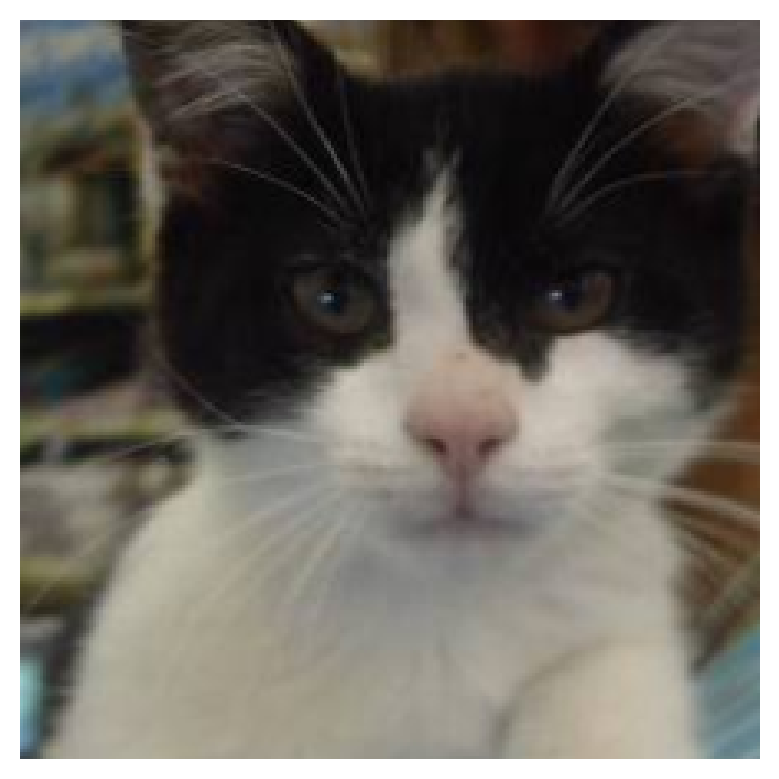

In [ ]:
# Run this to test your data loader
images, labels = next(iter(dataloader))
imshow(images[0], normalize=False)

Si vous avez correctement chargé les données, vous devriez obtenir un affichage similaire à celui-ci (votre image sera différente) :




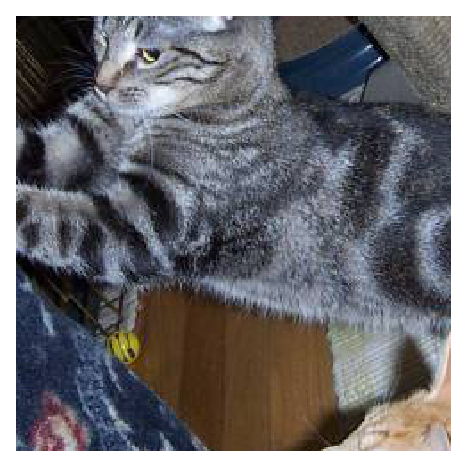


## Augmentation de Données

Une stratégie courante pour entraîner des réseaux de neurones consiste à introduire une **certaine forme d’aléatoire dans les données d’entrée**.  
Par exemple, on peut faire tourner, refléter, redimensionner et/ou rogner aléatoirement les images pendant l’entraînement.  
Cela aide le réseau à **mieux généraliser**, car il voit les mêmes images sous différentes formes : positions, tailles, orientations, etc.

Pour appliquer une rotation, un recadrage et un redimensionnement aléatoires, puis retourner les images horizontalement, on peut définir les transformations ainsi :

```python
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])
````

Il est également recommandé de **normaliser les images** à l’aide de `transforms.Normalize`.
Cette transformation prend en entrée :

* une liste de **moyennes** (`mean`)
* et une liste d’**écarts-types** (`std`)

Chaque canal de couleur est alors normalisé selon la formule :

```
input[channel] = (input[channel] - mean[channel]) / std[channel]
```

Soustraire la moyenne recentre les données autour de zéro,
et diviser par l’écart-type comprime les valeurs entre **-1 et 1**.
Cette normalisation aide à maintenir les **poids du réseau proches de zéro**,
rendant ainsi la **rétropropagation plus stable**.
Sans normalisation, le réseau risque souvent d’échouer à apprendre correctement.

Vous pouvez consulter la **liste complète des transformations disponibles** [ici](http://pytorch.org/docs/0.3.0/torchvision/transforms.html).

Lors des phases de **validation** ou de **test**, on utilise généralement des images **non altérées** (hormis la normalisation).
Ainsi, pour les données de validation ou de test, on se contente en général de **redimensionner** et **recadrer** les images.

---

> **Exercice :**
> Définissez ci-dessous les **transformations** pour les données d’entraînement et de test.
> Ne mettez pas encore la normalisation.

```



In [ ]:
data_dir = 'Cat_Dog_data'

# TODO: Define transforms for the training data and testing data
train_transforms = transforms.Compose([
    #transforms.CenterCrop(30),
    #transforms.AutoAugment(),
    transforms.Resize(224),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transforms =transforms.Compose([
    #transforms.CenterCrop(10),
    transforms.Resize(224),
    transforms.ToTensor()
])


# Pass transforms in here, then run the next cell to see how the transforms look
train_data = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
test_data = datasets.ImageFolder(data_dir + '/test', transform=test_transforms)

trainloader = torch.utils.data.DataLoader(train_data, batch_size=32)
testloader = torch.utils.data.DataLoader(test_data, batch_size=32)

In [ ]:
# change this to the trainloader or testloader
data_iter = iter(trainloader)

In [ ]:
images, labels = next(data_iter)
labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])

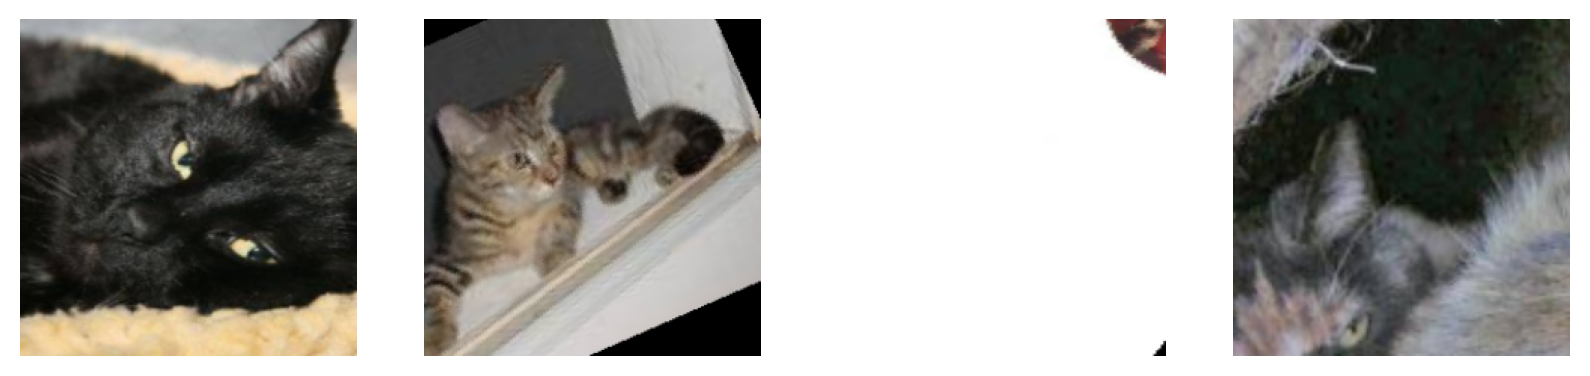

In [ ]:


images, labels = next(data_iter)
fig, axes = plt.subplots(figsize=(10,4), ncols=4)
for ii in range(4):
    ax = axes[ii]
    imshow(images[ii], ax=ax, normalize=False)

Vos images transformées devraient ressembler à quelque chose comme ceci.




<center>Training examples:</center>


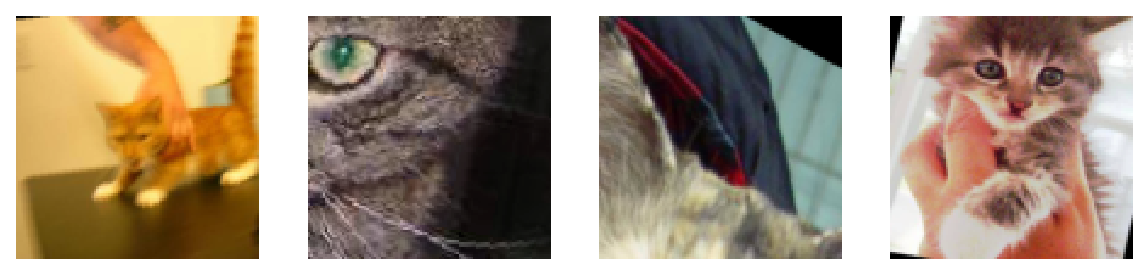

<center>Testing examples:</center>

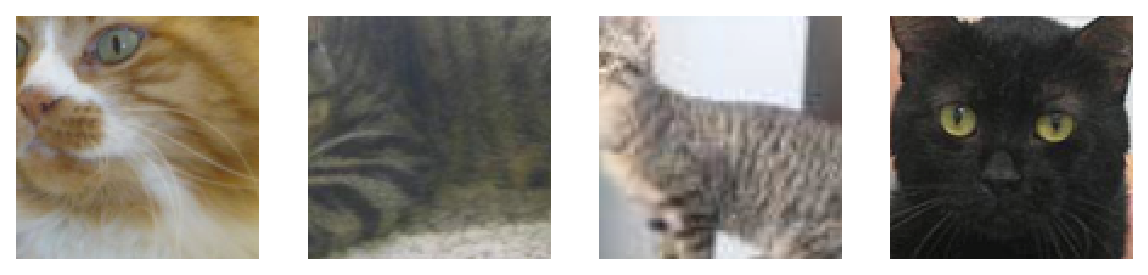


À ce stade, vous devriez être en mesure de charger les données pour l’entraînement et le test.  
Vous pouvez maintenant essayer de construire un réseau capable de **classer les chats et les chiens**.



# DEVOIR – CNN “from scratch” vs Transfert Learning (Cats vs Dogs)

## Objectif

Comparer **un modèle CNN entraîné from scratch** et **un modèle en transfert d’apprentissage** sur le même jeu de données (cats vs dogs). Montrer l’impact du transfert learning sur la convergence, la performance et la robustesse.

## Ce qui est **obligatoire**

1. **Deux expériences distinctes**

   * Expérience A : CNN **from scratch** (architecture simple minimum 3 bloc avec conv).
   * Expérience B : **Transfert learning** (ex. ResNet, MobileNet, EfficientNet…), couches finales adaptées.
2. **Bonnes pratiques de régularisation**

   * Utiliser **Dropout** ET **Batch Normalization** (justifier où et pourquoi).
3. **Suivi des métriques**

   * **Training loss**, **Accuracy**, **Précision**, **Recall** à chaque époque (et idéalement sur train/val si vous faites une validation).
   * Tracer des **courbes** et **comparer** les deux approches.
4. **Optimisation**

   * Tester au moins **2 optimiseurs** (ex. SGD et Adam).
   * Chercher un **bon learning rate** (essais ou scheduler).
5. **GPU**

   * Entraîner **sur GPU** si disponible (vérification et mention dans README).
6. **Persistance du modèle**

   * **Sauvegarder** le meilleur modèle (.pt/.pth) localement (ne **pas** pousser dans GitHub).
   * **Recharger** le modèle pour faire le **test final** et rapporter les métriques.
7. **Reproductibilité**

   * Fixer un **seed**

## Ce qui est **souhaité (bonus)**

* **Split train/validation** (clair et justifié).
* **Data augmentation** raisonnable.
* **Scheduler** (ex. StepLR, CosineAnnealingLR).
* **Matrice de confusion** et quelques **erreurs typiques** commentées.
* Journalisation (TensorBoard/W&B) — sans pousser les fichiers lourds.

## Données

* Utilisez le même corpus **Cats vs Dogs** que vu en cours (ou équivalent).
* Ne **poussez pas** les données sur GitHub. Indiquez seulement **comment** les télécharger/placer.

## Structure du dépôt GitHub (exemple)

```
cnn-catsdogs-<NomPrenom>/
├─ notebook.ipynb
├─ .gitignore
├─ requirements.txt (ou environment.yml)
├─ README.md
└─ LICENSE (optionnel)
```

### `.gitignore` (minimum)

```
data/
*.pt
*.pth
runs/
checkpoints/
```

## Contenu attendu du **README.md**

* **Titre & objectif** du projet.
* **Environnement** ( `pip install -r requirements.txt` ou `conda env create -f environment.yml`).
* **Organisation des données** (où télécharger, où placer les dossiers).
* **Commandes pour entraîner** :

  * From scratch : arguments clés (batch size, lr, epochs, optimiser, dropout, BN, scheduler…).
  * Transfert learning : même chose + quelle base (gel des couches ou fine-tuning).
* **Commandes pour évaluer / recharger le modèle** (chemin du checkpoint local).
* **Résultats** : tableaux + courbes (loss/accuracy/précision/recall) pour les deux expériences, **comparaison et analyse** (2–3 paragraphes).
* **Limites & pistes d’amélioration** (brèves).

## Évaluation (grille indicative)

* Rigueur expérimentale & métriques (30 %)
* Qualité des modèles & optimisation (25 %)
* Clarté du code & structure du dépôt (20 %)
* README (reproductibilité, analyse, figures) (20 %)
* Bonus (val split, augmentation, scheduler, confusion matrix) (5 %)

## Remise
* ** FAIRE une vidéo de 05 à 10 minute pour expliquer votre travail"
* Envoyez **le lien du dépôt** à **[diallomous@gmail.com](mailto:diallomous@gmail.com)**
* **Date limite : Vendredi 25 Septembre  avant 23h00. (Africa/Dakar).**

> Rappel :  Assurez-vous que votre dépôt permet de **reproduire** les expériences via les instructions du README.


---
# 🐱🐶 DEVOIR — CNN *from scratch* vs Transfer Learning

Cette section implémente **intégralement** le devoir décrit ci-dessus :

1. Reproductibilité (seed)
2. Vérification GPU
3. Split train / validation (bonus) + Data Augmentation (bonus)
4. Expérience A — CNN from scratch (3 blocs conv, BatchNorm + Dropout)
5. Expérience B — Transfer Learning (ResNet18 pré-entraîné)
6. Boucle d'entraînement générique avec suivi de **loss, accuracy, précision, recall** par époque
7. Test de **2 optimiseurs** (SGD et Adam) pour chaque expérience
8. **Scheduler** de learning rate (bonus)
9. Sauvegarde / rechargement du **meilleur modèle** (.pth)
10. Courbes de comparaison + **matrice de confusion** (bonus)
11. Évaluation finale sur le jeu de test à partir du modèle rechargé

> ⚠️ Avant de lancer cette section, assurez-vous que les cellules précédentes (montage Drive, dézippage de `Cat_Dog_data.zip`) ont bien été exécutées, de façon à avoir l'arborescence :
> ```
> Cat_Dog_data/
> ├── train/
> │   ├── cat/
> │   └── dog/
> └── test/
>     ├── cat/
>     └── dog/
> ```


## 1. Imports et configuration générale

In [ ]:
import os
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)


PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


## 2. Reproductibilité (seed)

On fixe toutes les sources d'aléatoire (Python, NumPy, PyTorch CPU/GPU) afin que les expériences soient **reproductibles**.

In [ ]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Pour un déterminisme maximal (peut ralentir un peu l'entraînement)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed fixée à {SEED}")


Seed fixée à 42


## 3. Vérification du GPU

Le devoir exige d'entraîner **sur GPU si disponible**. La cellule ci-dessous détecte automatiquement le device et l'utilise pour tous les entraînements.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("⚠️ Aucun GPU détecté. Sur Colab : Exécution > Modifier le type d'exécution > GPU")


Device utilisé : cuda
GPU : Tesla T4


## 4. Données : split train / validation + Data Augmentation (bonus)

**Pourquoi un split train/val ?**
Le dossier `Cat_Dog_data/train` sert à *entraîner*, mais nous avons aussi besoin d'un sous-ensemble de **validation**, non vu pendant l'optimisation des poids, afin de :
- suivre le sur-apprentissage (overfitting) époque par époque,
- sélectionner objectivement le **meilleur modèle** (celui qui minimise la loss de validation / maximise l'accuracy de validation) avant d'aller sur le jeu de test.

Le dossier `Cat_Dog_data/test` reste totalement à part, utilisé **uniquement** à la toute fin pour le score final.

**Astuce technique :** `ImageFolder` applique une seule transformation à tout le dataset. Pour appliquer des transformations *différentes* au train (avec augmentation) et à la validation (sans augmentation, comme le test), on charge **deux instances** d'`ImageFolder` sur le même dossier `train`, avec des transforms différents, puis on découpe les **indices** une seule fois (avec la seed fixée) pour que train et val correspondent aux mêmes images physiques sans chevauchement.

**Data Augmentation (bonus) :** rotation aléatoire, recadrage aléatoire, flip horizontal → aide le modèle à généraliser en voyant chaque image sous des variations réalistes (chat/chien peut être photographié sous n'importe quel angle).

In [ ]:
data_dir = "Cat_Dog_data"
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_FRACTION = 0.2  # 20% du train utilisé pour la validation

# ImageNet mean/std : requis car l'Expérience B réutilise un ResNet pré-entraîné sur ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Deux vues du même dossier train, avec des transforms différents
full_train_aug = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transforms)
full_train_eval = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=eval_transforms)

assert full_train_aug.classes == full_train_eval.classes
class_names = full_train_aug.classes
print("Classes :", class_names)

n_total = len(full_train_aug)
n_val = int(n_total * VAL_FRACTION)
n_train = n_total - n_val

set_seed(SEED)  # garantit un split identique à chaque exécution
indices = torch.randperm(n_total).tolist()
train_idx, val_idx = indices[:n_train], indices[n_train:]

train_data = Subset(full_train_aug, train_idx)   # avec augmentation
val_data = Subset(full_train_eval, val_idx)      # sans augmentation

test_data = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=eval_transforms)

print(f"Train : {len(train_data)} images | Val : {len(val_data)} images | Test : {len(test_data)} images")

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


Classes : ['cat', 'dog']
Train : 18000 images | Val : 4500 images | Test : 2500 images


## 5. Fonctions utilitaires : entraînement, évaluation, métriques

On définit :
- `train_one_epoch` : une époque d'entraînement (forward + backward + step), retourne loss et accuracy moyennes.
- `evaluate` : passe en mode `eval()` (désactive Dropout/BatchNorm en mode entraînement), calcule loss, accuracy, **précision** et **recall** (via `sklearn`, classification binaire chat=0 / chien=1).
- `run_training` : boucle complète sur plusieurs époques, avec **scheduler** optionnel, garde en mémoire le **meilleur modèle** (meilleure accuracy de validation) et l'historique des métriques pour tracer les courbes.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(all_labels)
    epoch_acc = (np.array(all_preds) == np.array(all_labels)).mean()
    epoch_prec = precision_score(all_labels, all_preds, zero_division=0)
    epoch_rec = recall_score(all_labels, all_preds, zero_division=0)
    return epoch_loss, epoch_acc, epoch_prec, epoch_rec, all_preds, all_labels


def run_training(model, train_loader, val_loader, optimizer, device,
                  n_epochs=10, scheduler=None, checkpoint_path="best_model.pth",
                  exp_name="experiment"):
    """Boucle d'entraînement complète avec suivi des métriques et sauvegarde du meilleur modèle."""
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": [], "val_prec": [], "val_rec": []}

    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_prec, val_rec, _, _ = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_prec"].append(val_prec)
        history["val_rec"].append(val_rec)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save({
                "model_state_dict": best_state,
                "val_acc": val_acc,
                "epoch": epoch,
                "exp_name": exp_name,
            }, checkpoint_path)

        dt = time.time() - t0
        print(f"[{exp_name}] Époque {epoch:02d}/{n_epochs} "
              f"- train_loss {train_loss:.4f} train_acc {train_acc:.4f} "
              f"- val_loss {val_loss:.4f} val_acc {val_acc:.4f} "
              f"val_prec {val_prec:.4f} val_rec {val_rec:.4f} "
              f"({dt:.1f}s)")

    # On recharge le meilleur modèle en mémoire à la fin
    model.load_state_dict(best_state)
    print(f"Meilleur val_acc pour {exp_name} : {best_val_acc:.4f} (sauvegardé dans {checkpoint_path})")
    return model, history


## 6. Expérience A — CNN *from scratch*

Architecture simple à **3 blocs convolutionnels** :

```
[Conv → BatchNorm → ReLU → MaxPool] x3 → Flatten → Dropout → Linear → Linear(2)
```

**Justification des choix de régularisation :**
- **BatchNorm** est placée **après chaque convolution, avant l'activation** : elle normalise les activations intermédiaires (moyenne 0, variance 1) ce qui stabilise et accélère l'entraînement, permet d'utiliser un learning rate plus élevé, et réduit la sensibilité à l'initialisation des poids.
- **Dropout** est placé **dans la partie fully-connected**, juste avant la dernière couche linéaire : c'est là que le modèle possède le plus de paramètres (donc le plus grand risque de sur-apprentissage), le Dropout force le réseau à ne pas dépendre d'un sous-ensemble restreint de neurones et améliore la généralisation. On ne met généralement pas de Dropout dans les couches convolutionnelles précoces, où l'information spatiale locale est encore importante.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 224 -> 112

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 112 -> 56

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56 -> 28
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # 128 x 1 x 1, robuste à la taille d'entrée
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p / 2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


set_seed(SEED)
model_scratch = SimpleCNN(num_classes=2).to(device)
print(model_scratch)
n_params = sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)
print(f"Nombre de paramètres entraînables : {n_params:,}")


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout

### 6.1 Expérience A — Optimiseur SGD

Test du premier optimiseur exigé par le devoir : **SGD** (avec momentum), avec un **scheduler** `StepLR` (bonus) qui réduit le learning rate au fil des époques.

In [ ]:
N_EPOCHS = 10
LR_SGD = 0.01

set_seed(SEED)
model_scratch_sgd = SimpleCNN(num_classes=2).to(device)
optimizer_sgd = optim.SGD(model_scratch_sgd.parameters(), lr=LR_SGD, momentum=0.9)
scheduler_sgd = optim.lr_scheduler.StepLR(optimizer_sgd, step_size=4, gamma=0.5)

model_scratch_sgd, hist_scratch_sgd = run_training(
    model_scratch_sgd, train_loader, val_loader, optimizer_sgd, device,
    n_epochs=N_EPOCHS, scheduler=scheduler_sgd,
    checkpoint_path="scratch_sgd_best.pth", exp_name="Scratch-SGD"
)


[Scratch-SGD] Époque 01/10 - train_loss 0.6666 train_acc 0.5876 - val_loss 0.6421 val_acc 0.6329 val_prec 0.6811 val_rec 0.5022 (98.1s)
[Scratch-SGD] Époque 02/10 - train_loss 0.6472 train_acc 0.6212 - val_loss 0.6297 val_acc 0.6309 val_prec 0.6055 val_rec 0.7551 (98.9s)
[Scratch-SGD] Époque 03/10 - train_loss 0.6417 train_acc 0.6251 - val_loss 0.6164 val_acc 0.6513 val_prec 0.6558 val_rec 0.6398 (96.8s)
[Scratch-SGD] Époque 04/10 - train_loss 0.6360 train_acc 0.6316 - val_loss 0.6053 val_acc 0.6560 val_prec 0.6177 val_rec 0.8221 (97.3s)
[Scratch-SGD] Époque 05/10 - train_loss 0.6230 train_acc 0.6519 - val_loss 0.5964 val_acc 0.6818 val_prec 0.6630 val_rec 0.7418 (97.4s)
[Scratch-SGD] Époque 06/10 - train_loss 0.6195 train_acc 0.6567 - val_loss 0.6010 val_acc 0.6724 val_prec 0.7664 val_rec 0.4978 (98.6s)
[Scratch-SGD] Époque 07/10 - train_loss 0.6150 train_acc 0.6630 - val_loss 0.5798 val_acc 0.7020 val_prec 0.7450 val_rec 0.6158 (96.6s)
[Scratch-SGD] Époque 08/10 - train_loss 0.6124 t

In [ ]:
N_EPOCHS = 10
LR_SGD = 0.01

set_seed(SEED)
model_scratch_sgd = SimpleCNN(num_classes=2).to(device)
optimizer_sgd = optim.SGD(model_scratch_sgd.parameters(), lr=LR_SGD, momentum=0.9)
scheduler_sgd = optim.lr_scheduler.StepLR(optimizer_sgd, step_size=4, gamma=0.5)

model_scratch_sgd, hist_scratch_sgd = run_training(
    model_scratch_sgd, train_loader, val_loader, optimizer_sgd, device,
    n_epochs=N_EPOCHS, scheduler=scheduler_sgd,
    checkpoint_path="scratch_sgd_best.pth", exp_name="Scratch-SGD"
)

[Scratch-SGD] Époque 01/10 - train_loss 0.6666 train_acc 0.5876 - val_loss 0.6421 val_acc 0.6329 val_prec 0.6811 val_rec 0.5022 (98.5s)
[Scratch-SGD] Époque 02/10 - train_loss 0.6472 train_acc 0.6212 - val_loss 0.6297 val_acc 0.6309 val_prec 0.6055 val_rec 0.7551 (96.5s)
[Scratch-SGD] Époque 03/10 - train_loss 0.6417 train_acc 0.6251 - val_loss 0.6164 val_acc 0.6513 val_prec 0.6558 val_rec 0.6398 (96.0s)
[Scratch-SGD] Époque 04/10 - train_loss 0.6360 train_acc 0.6316 - val_loss 0.6053 val_acc 0.6560 val_prec 0.6177 val_rec 0.8221 (96.9s)
[Scratch-SGD] Époque 05/10 - train_loss 0.6230 train_acc 0.6519 - val_loss 0.5964 val_acc 0.6818 val_prec 0.6630 val_rec 0.7418 (96.0s)
[Scratch-SGD] Époque 06/10 - train_loss 0.6195 train_acc 0.6567 - val_loss 0.6010 val_acc 0.6724 val_prec 0.7664 val_rec 0.4978 (98.4s)
[Scratch-SGD] Époque 07/10 - train_loss 0.6150 train_acc 0.6630 - val_loss 0.5798 val_acc 0.7020 val_prec 0.7450 val_rec 0.6158 (96.3s)
[Scratch-SGD] Époque 08/10 - train_loss 0.6124 t

In [ ]:
LR_ADAM = 1e-3

set_seed(SEED)
model_scratch_adam = SimpleCNN(num_classes=2).to(device)
optimizer_adam = optim.Adam(model_scratch_adam.parameters(), lr=LR_ADAM)
scheduler_adam = optim.lr_scheduler.CosineAnnealingLR(optimizer_adam, T_max=N_EPOCHS)

model_scratch_adam, hist_scratch_adam = run_training(
    model_scratch_adam, train_loader, val_loader, optimizer_adam, device,
    n_epochs=N_EPOCHS, scheduler=scheduler_adam,
    checkpoint_path="scratch_adam_best.pth", exp_name="Scratch-Adam"
)

[Scratch-Adam] Époque 01/10 - train_loss 0.6595 train_acc 0.5946 - val_loss 0.6344 val_acc 0.6444 val_prec 0.6163 val_rec 0.7689 (99.0s)
[Scratch-Adam] Époque 02/10 - train_loss 0.6346 train_acc 0.6364 - val_loss 0.6028 val_acc 0.6660 val_prec 0.6453 val_rec 0.7400 (95.5s)
[Scratch-Adam] Époque 03/10 - train_loss 0.6243 train_acc 0.6516 - val_loss 0.5835 val_acc 0.6844 val_prec 0.6765 val_rec 0.7090 (96.5s)
[Scratch-Adam] Époque 04/10 - train_loss 0.6157 train_acc 0.6581 - val_loss 0.5808 val_acc 0.6938 val_prec 0.6617 val_rec 0.7950 (97.1s)
[Scratch-Adam] Époque 05/10 - train_loss 0.6070 train_acc 0.6695 - val_loss 0.5870 val_acc 0.6884 val_prec 0.6463 val_rec 0.8350 (95.6s)
[Scratch-Adam] Époque 06/10 - train_loss 0.6008 train_acc 0.6753 - val_loss 0.5514 val_acc 0.7211 val_prec 0.7405 val_rec 0.6823 (97.9s)
[Scratch-Adam] Époque 07/10 - train_loss 0.5908 train_acc 0.6824 - val_loss 0.5426 val_acc 0.7344 val_prec 0.7243 val_rec 0.7587 (97.8s)
[Scratch-Adam] Époque 08/10 - train_loss 

In [ ]:
best_scratch_name = "SGD" if max(hist_scratch_sgd["val_acc"]) >= max(hist_scratch_adam["val_acc"]) else "Adam"
if best_scratch_name == "SGD":
    model_scratch_best = model_scratch_sgd
    hist_scratch_best = hist_scratch_sgd
    best_scratch_ckpt = "scratch_sgd_best.pth"
else:
    model_scratch_best = model_scratch_adam
    hist_scratch_best = hist_scratch_adam
    best_scratch_ckpt = "scratch_adam_best.pth"

print(f"Meilleur optimiseur pour le CNN from scratch : {best_scratch_name} "
      f"(val_acc = {max(hist_scratch_best['val_acc']):.4f})")

Meilleur optimiseur pour le CNN from scratch : Adam (val_acc = 0.7422)


In [ ]:
import torch.nn as nn
import torchvision.models as models

def build_resnet_transfer(num_classes=2, dropout_p=0.5):
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    # Gel des couches convolutionnelles pré-entraînées (feature extractor)
    for param in model.parameters():
        param.requires_grad = False

    # Remplacement de la tête de classification (Dropout + Linear, entraînable)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout_p),
        nn.Linear(in_features, num_classes),
    )
    return model

set_seed(SEED)
model_tl_sgd = build_resnet_transfer(num_classes=2).to(device)
# Seuls les paramètres entraînables (la tête `fc`) sont passés à l'optimiseur
optimizer_tl_sgd = optim.SGD(model_tl_sgd.fc.parameters(), lr=LR_SGD, momentum=0.9)
scheduler_tl_sgd = optim.lr_scheduler.StepLR(optimizer_tl_sgd, step_size=4, gamma=0.5)

model_tl_sgd, hist_tl_sgd = run_training(
    model_tl_sgd, train_loader, val_loader, optimizer_tl_sgd, device,
    n_epochs=N_EPOCHS, scheduler=scheduler_tl_sgd,
    checkpoint_path="tl_sgd_best.pth", exp_name="TransferLearning-SGD"
)

[TransferLearning-SGD] Époque 01/10 - train_loss 0.5887 train_acc 0.8539 - val_loss 0.0775 val_acc 0.9753 val_prec 0.9629 val_rec 0.9889 (100.3s)
[TransferLearning-SGD] Époque 02/10 - train_loss 0.5729 train_acc 0.8640 - val_loss 0.0708 val_acc 0.9776 val_prec 0.9782 val_rec 0.9769 (94.5s)
[TransferLearning-SGD] Époque 03/10 - train_loss 0.6362 train_acc 0.8533 - val_loss 0.0791 val_acc 0.9749 val_prec 0.9908 val_rec 0.9587 (96.3s)
[TransferLearning-SGD] Époque 04/10 - train_loss 0.6359 train_acc 0.8582 - val_loss 0.0754 val_acc 0.9758 val_prec 0.9855 val_rec 0.9658 (93.1s)
[TransferLearning-SGD] Époque 05/10 - train_loss 0.4857 train_acc 0.8737 - val_loss 0.0544 val_acc 0.9782 val_prec 0.9791 val_rec 0.9774 (93.6s)
[TransferLearning-SGD] Époque 06/10 - train_loss 0.4166 train_acc 0.8649 - val_loss 0.0764 val_acc 0.9693 val_prec 0.9876 val_rec 0.9508 (93.7s)
[TransferLearning-SGD] Époque 07/10 - train_loss 0.4048 train_acc 0.8626 - val_loss 0.1284 val_acc 0.9558 val_prec 0.9196 val_rec

In [ ]:
set_seed(SEED)
model_tl_adam = build_resnet_transfer(num_classes=2).to(device)
optimizer_tl_adam = optim.Adam(model_tl_adam.fc.parameters(), lr=LR_ADAM)
scheduler_tl_adam = optim.lr_scheduler.CosineAnnealingLR(optimizer_tl_adam, T_max=N_EPOCHS)

model_tl_adam, hist_tl_adam = run_training(
    model_tl_adam, train_loader, val_loader, optimizer_tl_adam, device,
    n_epochs=N_EPOCHS, scheduler=scheduler_tl_adam,
    checkpoint_path="tl_adam_best.pth", exp_name="TransferLearning-Adam"
)

[TransferLearning-Adam] Époque 01/10 - train_loss 0.2947 train_acc 0.8622 - val_loss 0.0680 val_acc 0.9760 val_prec 0.9735 val_rec 0.9787 (93.8s)
[TransferLearning-Adam] Époque 02/10 - train_loss 0.2457 train_acc 0.8916 - val_loss 0.0644 val_acc 0.9762 val_prec 0.9625 val_rec 0.9911 (93.3s)
[TransferLearning-Adam] Époque 03/10 - train_loss 0.2579 train_acc 0.8866 - val_loss 0.0655 val_acc 0.9760 val_prec 0.9625 val_rec 0.9907 (92.9s)
[TransferLearning-Adam] Époque 04/10 - train_loss 0.2493 train_acc 0.8893 - val_loss 0.0594 val_acc 0.9802 val_prec 0.9822 val_rec 0.9783 (93.1s)
[TransferLearning-Adam] Époque 05/10 - train_loss 0.2441 train_acc 0.8918 - val_loss 0.0623 val_acc 0.9764 val_prec 0.9629 val_rec 0.9911 (92.9s)
[TransferLearning-Adam] Époque 06/10 - train_loss 0.2568 train_acc 0.8866 - val_loss 0.0615 val_acc 0.9793 val_prec 0.9783 val_rec 0.9805 (92.9s)
[TransferLearning-Adam] Époque 07/10 - train_loss 0.2430 train_acc 0.8891 - val_loss 0.0606 val_acc 0.9780 val_prec 0.9687 v

In [27]:
best_tl_name = "SGD" if max(hist_tl_sgd["val_acc"]) >= max(hist_tl_adam["val_acc"]) else "Adam"
if best_tl_name == "SGD":
    model_tl_best = model_tl_sgd
    hist_tl_best = hist_tl_sgd
    best_tl_ckpt = "tl_sgd_best.pth"
else:
    model_tl_best = model_tl_adam
    hist_tl_best = hist_tl_adam
    best_tl_ckpt = "tl_adam_best.pth"

print(f"Meilleur optimiseur pour le Transfer Learning : {best_tl_name} "
      f"(val_acc = {max(hist_tl_best['val_acc']):.4f})")

Meilleur optimiseur pour le Transfer Learning : Adam (val_acc = 0.9802)


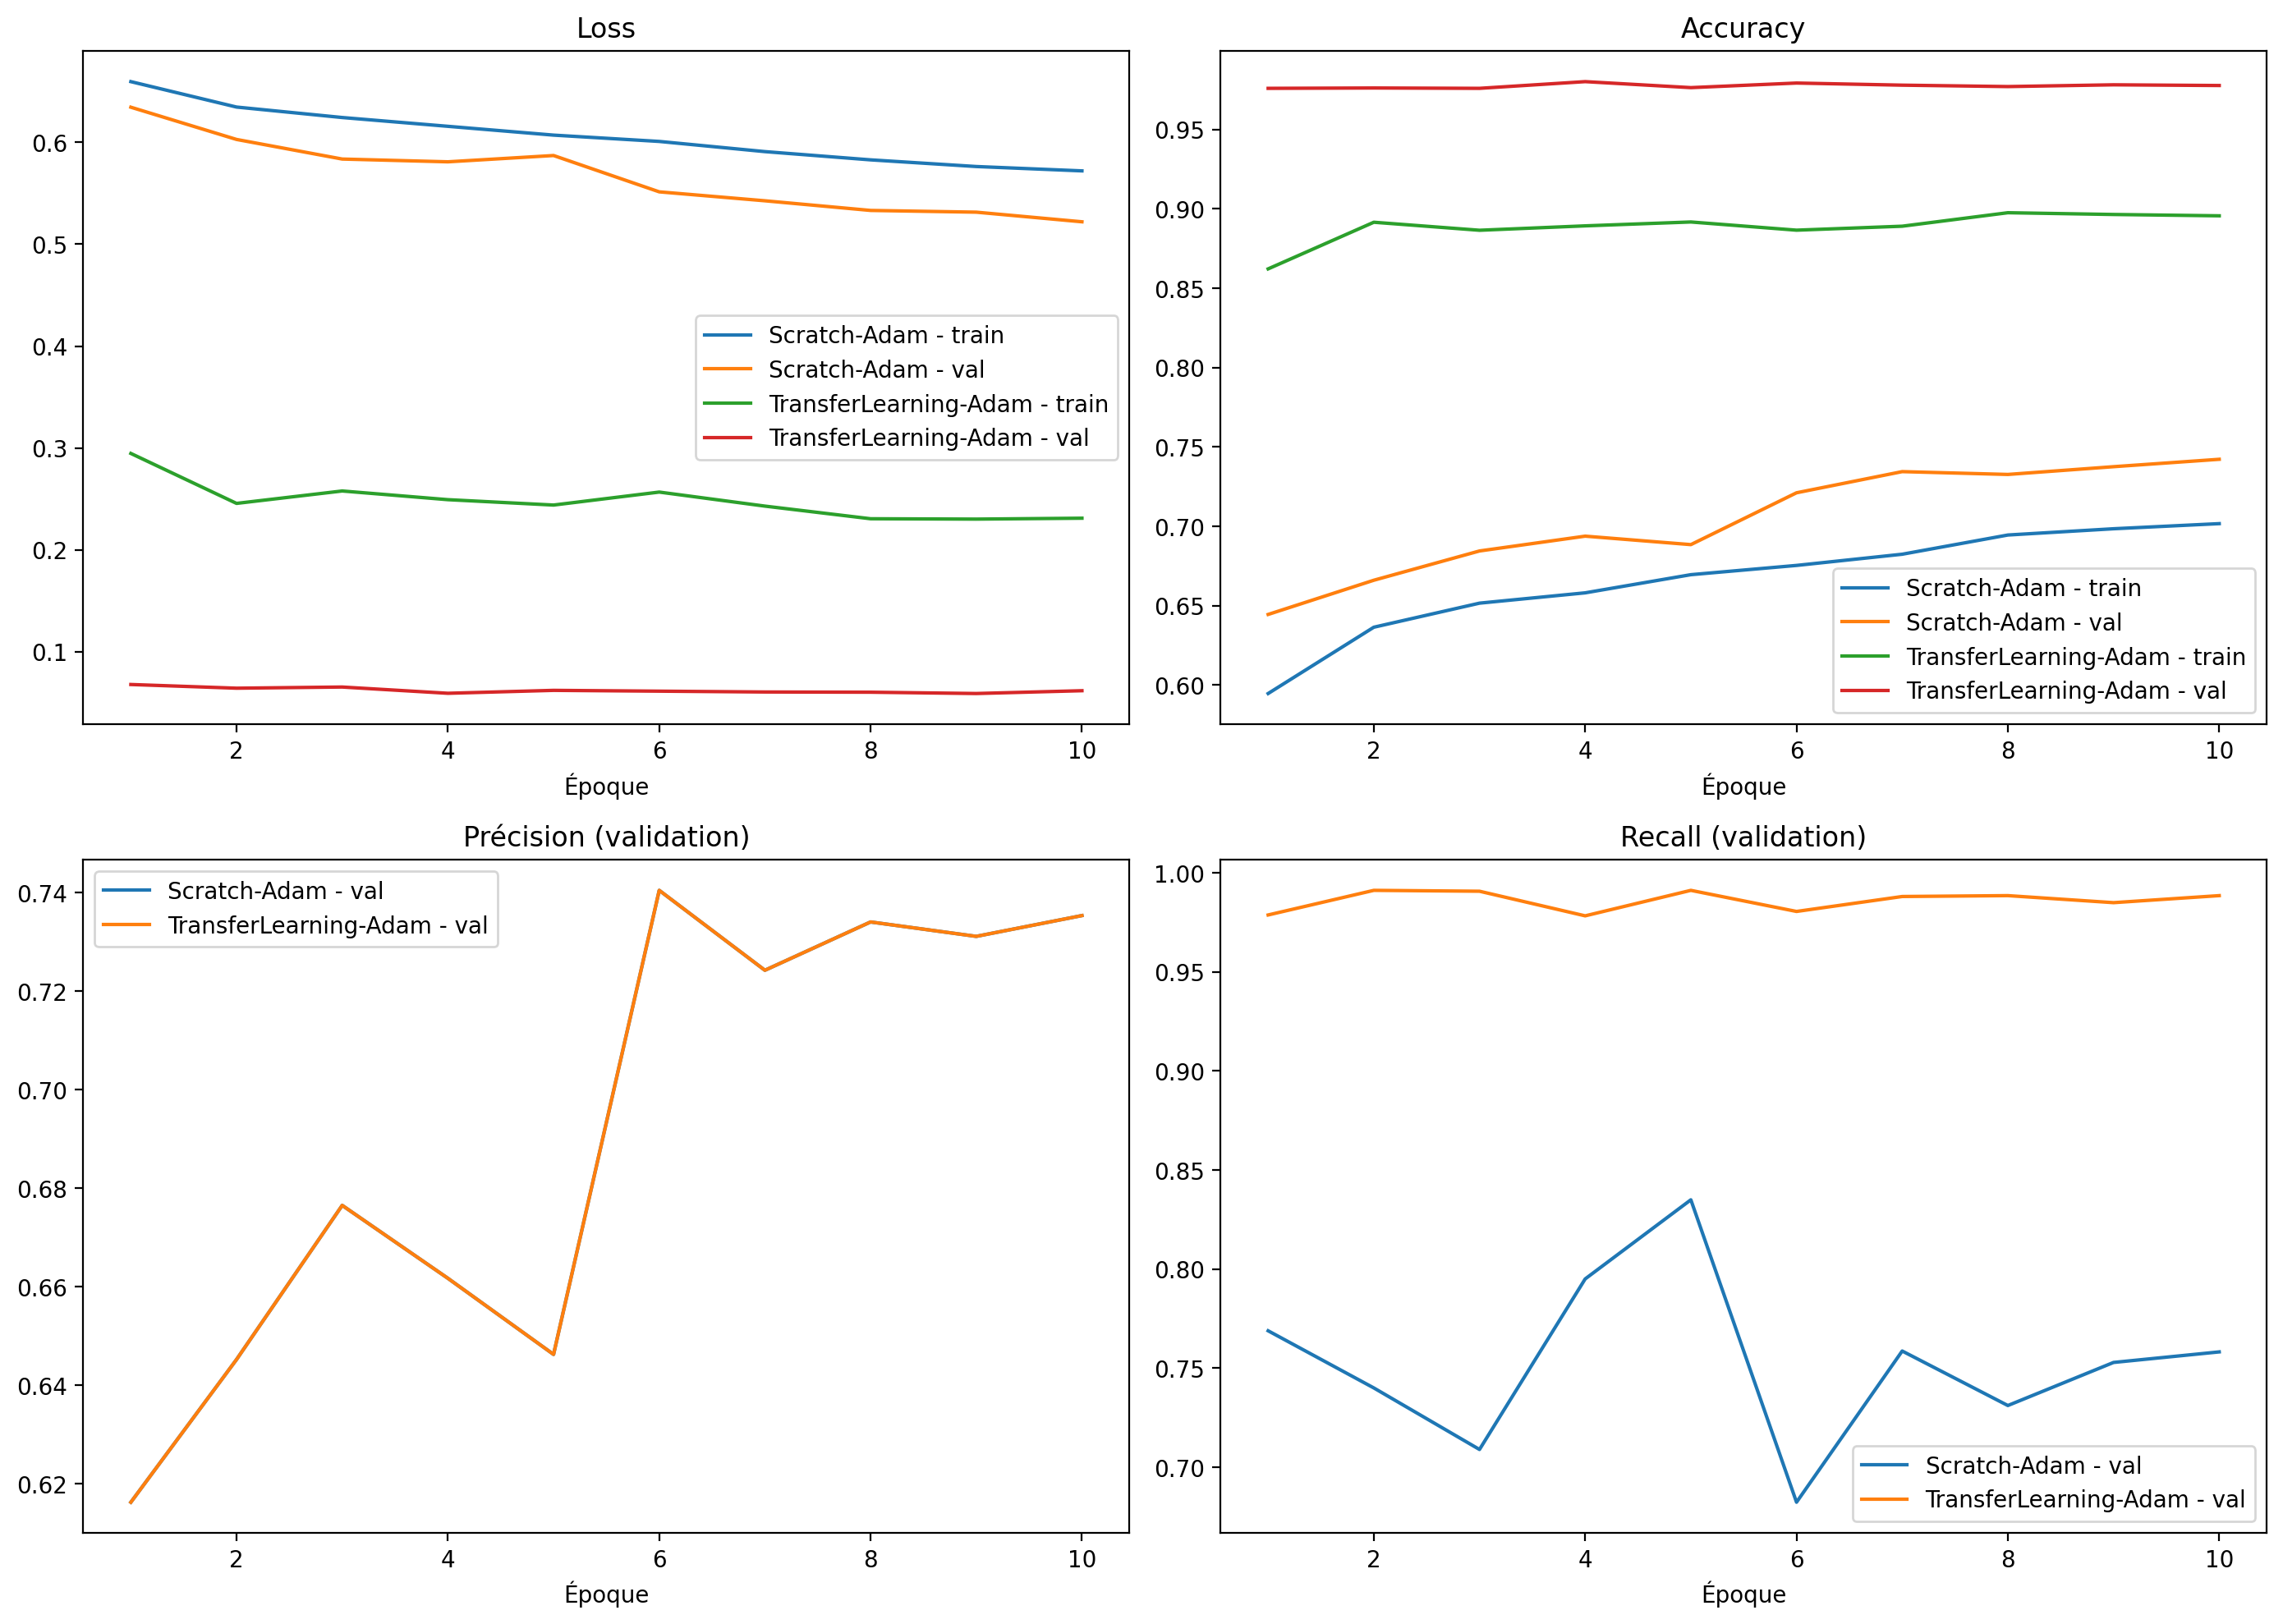

In [28]:
def plot_comparison(hist_a, name_a, hist_b, name_b):
    epochs = range(1, len(hist_a["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(epochs, hist_a["train_loss"], label=f"{name_a} - train")
    axes[0, 0].plot(epochs, hist_a["val_loss"], label=f"{name_a} - val")
    axes[0, 0].plot(epochs, hist_b["train_loss"], label=f"{name_b} - train")
    axes[0, 0].plot(epochs, hist_b["val_loss"], label=f"{name_b} - val")
    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Époque"); axes[0, 0].legend()

    axes[0, 1].plot(epochs, hist_a["train_acc"], label=f"{name_a} - train")
    axes[0, 1].plot(epochs, hist_a["val_acc"], label=f"{name_a} - val")
    axes[0, 1].plot(epochs, hist_b["train_acc"], label=f"{name_b} - train")
    axes[0, 1].plot(epochs, hist_b["val_acc"], label=f"{name_b} - val")
    axes[0, 1].set_title("Accuracy")
    axes[0, 1].set_xlabel("Époque"); axes[0, 1].legend()

    axes[1, 0].plot(epochs, hist_a["val_prec"], label=f"{name_a} - val")
    axes[1, 0].plot(epochs, hist_a["val_prec"], label=f"{name_b} - val")
    axes[1, 0].set_title("Précision (validation)")
    axes[1, 0].set_xlabel("Époque"); axes[1, 0].legend()

    axes[1, 1].plot(epochs, hist_a["val_rec"], label=f"{name_a} - val")
    axes[1, 1].plot(epochs, hist_b["val_rec"], label=f"{name_b} - val")
    axes[1, 1].set_title("Recall (validation)")
    axes[1, 1].set_xlabel("Époque"); axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig("comparison_curves.png", dpi=150)
    plt.show()

plot_comparison(hist_scratch_best, f"Scratch-{best_scratch_name}",
                 hist_tl_best, f"TransferLearning-{best_tl_name}")

### 6.2 Expérience A — Optimiseur Adam

Test du second optimiseur exigé : **Adam**, généralement plus rapide à converger, avec un learning rate plus faible (typique pour Adam) et un scheduler `CosineAnnealingLR` (bonus).

In [29]:
LR_ADAM = 1e-3

set_seed(SEED)
model_scratch_adam = SimpleCNN(num_classes=2).to(device)
optimizer_adam = optim.Adam(model_scratch_adam.parameters(), lr=LR_ADAM)
scheduler_adam = optim.lr_scheduler.CosineAnnealingLR(optimizer_adam, T_max=N_EPOCHS)

model_scratch_adam, hist_scratch_adam = run_training(
    model_scratch_adam, train_loader, val_loader, optimizer_adam, device,
    n_epochs=N_EPOCHS, scheduler=scheduler_adam,
    checkpoint_path="scratch_adam_best.pth", exp_name="Scratch-Adam"
)


[Scratch-Adam] Époque 01/10 - train_loss 0.6595 train_acc 0.5946 - val_loss 0.6344 val_acc 0.6444 val_prec 0.6163 val_rec 0.7689 (102.4s)
[Scratch-Adam] Époque 02/10 - train_loss 0.6346 train_acc 0.6364 - val_loss 0.6028 val_acc 0.6660 val_prec 0.6453 val_rec 0.7400 (97.4s)
[Scratch-Adam] Époque 03/10 - train_loss 0.6243 train_acc 0.6516 - val_loss 0.5835 val_acc 0.6844 val_prec 0.6765 val_rec 0.7090 (103.2s)
[Scratch-Adam] Époque 04/10 - train_loss 0.6157 train_acc 0.6581 - val_loss 0.5808 val_acc 0.6938 val_prec 0.6617 val_rec 0.7950 (99.5s)
[Scratch-Adam] Époque 05/10 - train_loss 0.6070 train_acc 0.6695 - val_loss 0.5870 val_acc 0.6884 val_prec 0.6463 val_rec 0.8350 (97.9s)
[Scratch-Adam] Époque 06/10 - train_loss 0.6008 train_acc 0.6753 - val_loss 0.5514 val_acc 0.7211 val_prec 0.7405 val_rec 0.6823 (99.0s)
[Scratch-Adam] Époque 07/10 - train_loss 0.5908 train_acc 0.6824 - val_loss 0.5426 val_acc 0.7344 val_prec 0.7243 val_rec 0.7587 (96.8s)
[Scratch-Adam] Époque 08/10 - train_los

### 6.3 Choix du meilleur optimiseur pour l'Expérience A

On compare les deux historiques et on retient, pour la suite (comparaison finale vs Transfer Learning), celui qui obtient la meilleure `val_acc`.

In [30]:
best_scratch_name = "SGD" if max(hist_scratch_sgd["val_acc"]) >= max(hist_scratch_adam["val_acc"]) else "Adam"
if best_scratch_name == "SGD":
    model_scratch_best = model_scratch_sgd
    hist_scratch_best = hist_scratch_sgd
    best_scratch_ckpt = "scratch_sgd_best.pth"
else:
    model_scratch_best = model_scratch_adam
    hist_scratch_best = hist_scratch_adam
    best_scratch_ckpt = "scratch_adam_best.pth"

print(f"Meilleur optimiseur pour le CNN from scratch : {best_scratch_name} "
      f"(val_acc = {max(hist_scratch_best['val_acc']):.4f})")


Meilleur optimiseur pour le CNN from scratch : Adam (val_acc = 0.7422)


## 7. Expérience B — Transfer Learning (ResNet18)

On réutilise **ResNet18 pré-entraîné sur ImageNet**. Les couches convolutionnelles (extraction de features génériques : contours, textures, formes) sont **gelées** (`requires_grad=False`) car elles ont déjà appris des représentations visuelles utiles et transférables ; seule la dernière couche fully-connected est remplacée et entraînée pour notre tâche à 2 classes (chat/chien). C'est le principe du *feature extraction* en transfer learning (par opposition au *fine-tuning* complet, plus coûteux et pas nécessaire ici vu la proximité du domaine avec ImageNet).

In [31]:
def build_resnet_transfer(num_classes=2, dropout_p=0.5):
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    # Gel des couches convolutionnelles pré-entraînées (feature extractor)
    for param in model.parameters():
        param.requires_grad = False

    # Remplacement de la tête de classification (Dropout + Linear, entraînable)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout_p),
        nn.Linear(in_features, num_classes),
    )
    return model


### 7.1 Transfer Learning — Optimiseur SGD

In [32]:
set_seed(SEED)
model_tl_sgd = build_resnet_transfer(num_classes=2).to(device)
# Seuls les paramètres entraînables (la tête `fc`) sont passés à l'optimiseur
optimizer_tl_sgd = optim.SGD(model_tl_sgd.fc.parameters(), lr=LR_SGD, momentum=0.9)
scheduler_tl_sgd = optim.lr_scheduler.StepLR(optimizer_tl_sgd, step_size=4, gamma=0.5)

model_tl_sgd, hist_tl_sgd = run_training(
    model_tl_sgd, train_loader, val_loader, optimizer_tl_sgd, device,
    n_epochs=N_EPOCHS, scheduler=scheduler_tl_sgd,
    checkpoint_path="tl_sgd_best.pth", exp_name="TransferLearning-SGD"
)


[TransferLearning-SGD] Époque 01/10 - train_loss 0.5887 train_acc 0.8539 - val_loss 0.0775 val_acc 0.9753 val_prec 0.9629 val_rec 0.9889 (93.1s)
[TransferLearning-SGD] Époque 02/10 - train_loss 0.5729 train_acc 0.8640 - val_loss 0.0708 val_acc 0.9776 val_prec 0.9782 val_rec 0.9769 (97.2s)
[TransferLearning-SGD] Époque 03/10 - train_loss 0.6362 train_acc 0.8533 - val_loss 0.0791 val_acc 0.9749 val_prec 0.9908 val_rec 0.9587 (93.1s)
[TransferLearning-SGD] Époque 04/10 - train_loss 0.6359 train_acc 0.8582 - val_loss 0.0754 val_acc 0.9758 val_prec 0.9855 val_rec 0.9658 (93.4s)
[TransferLearning-SGD] Époque 05/10 - train_loss 0.4857 train_acc 0.8737 - val_loss 0.0544 val_acc 0.9782 val_prec 0.9791 val_rec 0.9774 (92.7s)
[TransferLearning-SGD] Époque 06/10 - train_loss 0.4166 train_acc 0.8649 - val_loss 0.0764 val_acc 0.9693 val_prec 0.9876 val_rec 0.9508 (91.9s)
[TransferLearning-SGD] Époque 07/10 - train_loss 0.4048 train_acc 0.8626 - val_loss 0.1284 val_acc 0.9558 val_prec 0.9196 val_rec 

### 7.2 Transfer Learning — Optimiseur Adam

In [33]:
set_seed(SEED)
model_tl_adam = build_resnet_transfer(num_classes=2).to(device)
optimizer_tl_adam = optim.Adam(model_tl_adam.fc.parameters(), lr=LR_ADAM)
scheduler_tl_adam = optim.lr_scheduler.CosineAnnealingLR(optimizer_tl_adam, T_max=N_EPOCHS)

model_tl_adam, hist_tl_adam = run_training(
    model_tl_adam, train_loader, val_loader, optimizer_tl_adam, device,
    n_epochs=N_EPOCHS, scheduler=scheduler_tl_adam,
    checkpoint_path="tl_adam_best.pth", exp_name="TransferLearning-Adam"
)


[TransferLearning-Adam] Époque 01/10 - train_loss 0.2947 train_acc 0.8622 - val_loss 0.0680 val_acc 0.9760 val_prec 0.9735 val_rec 0.9787 (98.2s)
[TransferLearning-Adam] Époque 02/10 - train_loss 0.2457 train_acc 0.8916 - val_loss 0.0644 val_acc 0.9762 val_prec 0.9625 val_rec 0.9911 (92.9s)
[TransferLearning-Adam] Époque 03/10 - train_loss 0.2579 train_acc 0.8866 - val_loss 0.0655 val_acc 0.9760 val_prec 0.9625 val_rec 0.9907 (92.9s)
[TransferLearning-Adam] Époque 04/10 - train_loss 0.2493 train_acc 0.8893 - val_loss 0.0594 val_acc 0.9802 val_prec 0.9822 val_rec 0.9783 (94.7s)
[TransferLearning-Adam] Époque 05/10 - train_loss 0.2441 train_acc 0.8918 - val_loss 0.0623 val_acc 0.9764 val_prec 0.9629 val_rec 0.9911 (94.6s)
[TransferLearning-Adam] Époque 06/10 - train_loss 0.2568 train_acc 0.8866 - val_loss 0.0615 val_acc 0.9793 val_prec 0.9783 val_rec 0.9805 (94.7s)
[TransferLearning-Adam] Époque 07/10 - train_loss 0.2430 train_acc 0.8891 - val_loss 0.0606 val_acc 0.9780 val_prec 0.9687 v

### 7.3 Choix du meilleur optimiseur pour l'Expérience B

In [34]:
best_tl_name = "SGD" if max(hist_tl_sgd["val_acc"]) >= max(hist_tl_adam["val_acc"]) else "Adam"
if best_tl_name == "SGD":
    model_tl_best = model_tl_sgd
    hist_tl_best = hist_tl_sgd
    best_tl_ckpt = "tl_sgd_best.pth"
else:
    model_tl_best = model_tl_adam
    hist_tl_best = hist_tl_adam
    best_tl_ckpt = "tl_adam_best.pth"

print(f"Meilleur optimiseur pour le Transfer Learning : {best_tl_name} "
      f"(val_acc = {max(hist_tl_best['val_acc']):.4f})")


Meilleur optimiseur pour le Transfer Learning : Adam (val_acc = 0.9802)


## 8. Courbes de comparaison — Scratch vs Transfer Learning

On trace, pour les meilleures configurations de chaque expérience : la loss, l'accuracy, la précision et le recall, sur train et validation, en fonction des époques.

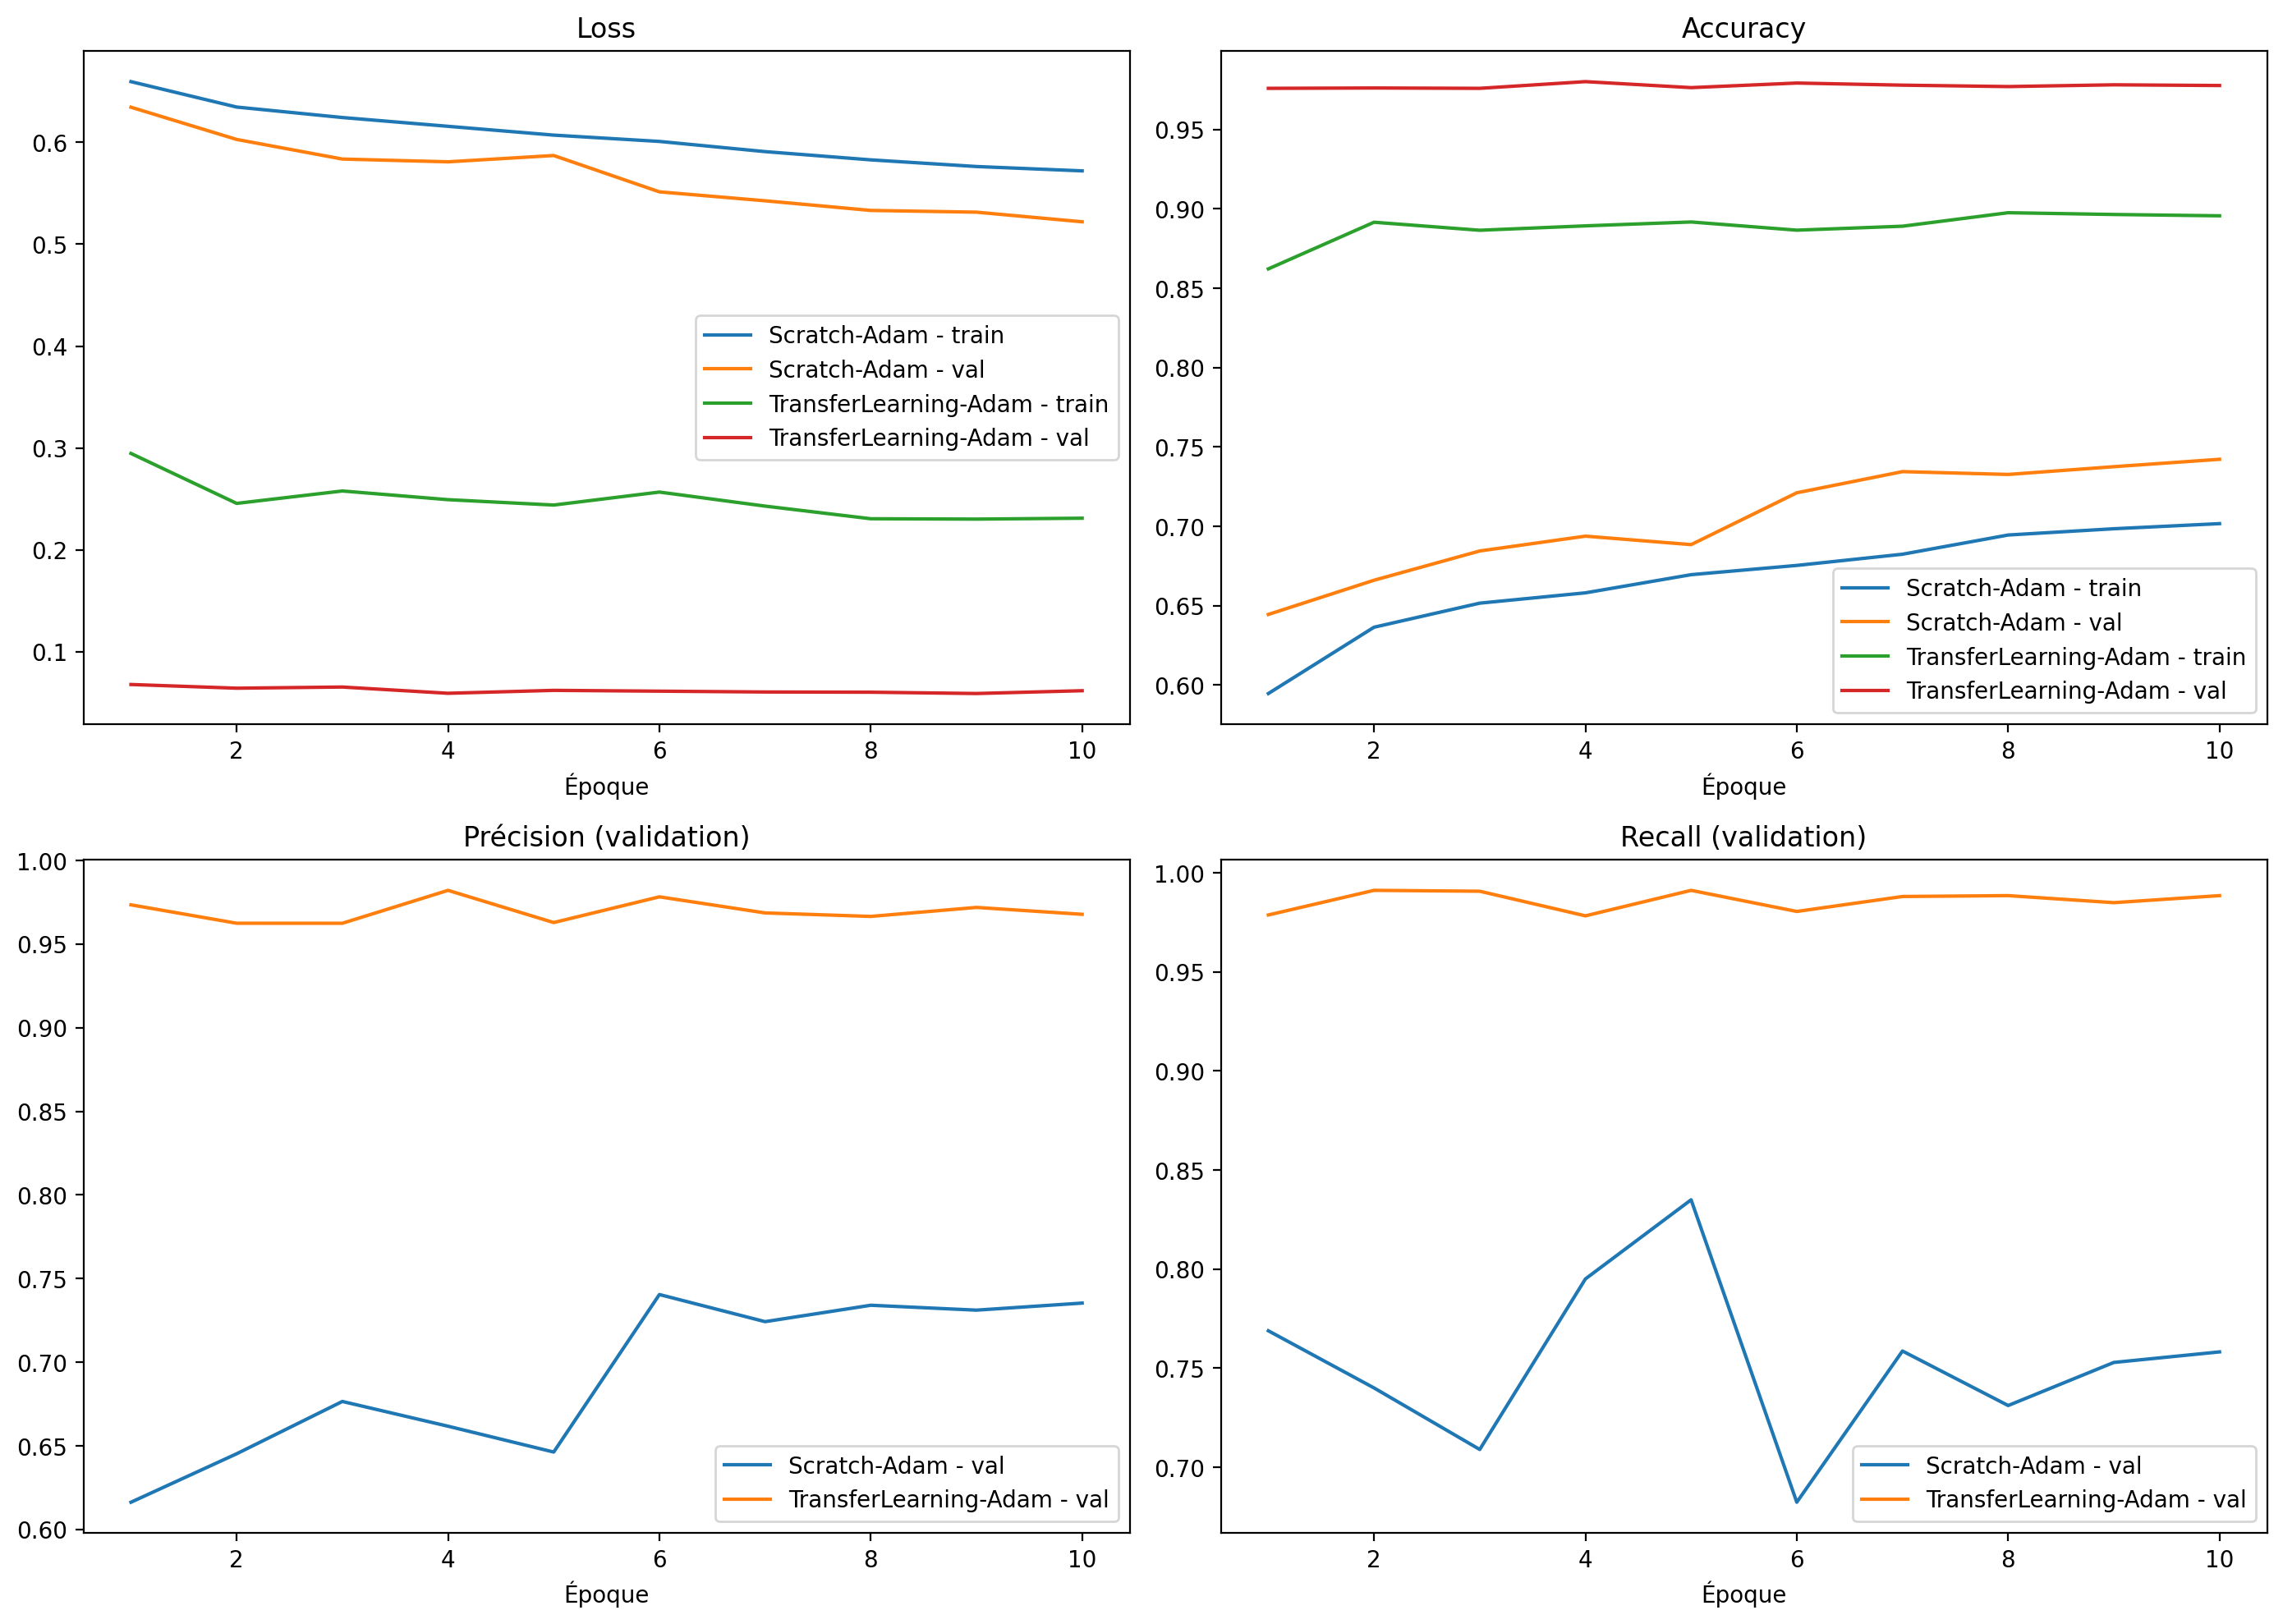

In [35]:
def plot_comparison(hist_a, name_a, hist_b, name_b):
    epochs = range(1, len(hist_a["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(epochs, hist_a["train_loss"], label=f"{name_a} - train")
    axes[0, 0].plot(epochs, hist_a["val_loss"], label=f"{name_a} - val")
    axes[0, 0].plot(epochs, hist_b["train_loss"], label=f"{name_b} - train")
    axes[0, 0].plot(epochs, hist_b["val_loss"], label=f"{name_b} - val")
    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Époque"); axes[0, 0].legend()

    axes[0, 1].plot(epochs, hist_a["train_acc"], label=f"{name_a} - train")
    axes[0, 1].plot(epochs, hist_a["val_acc"], label=f"{name_a} - val")
    axes[0, 1].plot(epochs, hist_b["train_acc"], label=f"{name_b} - train")
    axes[0, 1].plot(epochs, hist_b["val_acc"], label=f"{name_b} - val")
    axes[0, 1].set_title("Accuracy")
    axes[0, 1].set_xlabel("Époque"); axes[0, 1].legend()

    axes[1, 0].plot(epochs, hist_a["val_prec"], label=f"{name_a} - val")
    axes[1, 0].plot(epochs, hist_b["val_prec"], label=f"{name_b} - val")
    axes[1, 0].set_title("Précision (validation)")
    axes[1, 0].set_xlabel("Époque"); axes[1, 0].legend()

    axes[1, 1].plot(epochs, hist_a["val_rec"], label=f"{name_a} - val")
    axes[1, 1].plot(epochs, hist_b["val_rec"], label=f"{name_b} - val")
    axes[1, 1].set_title("Recall (validation)")
    axes[1, 1].set_xlabel("Époque"); axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig("comparison_curves.png", dpi=150)
    plt.show()

plot_comparison(hist_scratch_best, f"Scratch-{best_scratch_name}",
                 hist_tl_best, f"TransferLearning-{best_tl_name}")


## 9. Matrice de confusion (bonus) — sur le jeu de validation

Permet de visualiser les erreurs typiques (chats classés chiens et inversement) pour chaque approche.

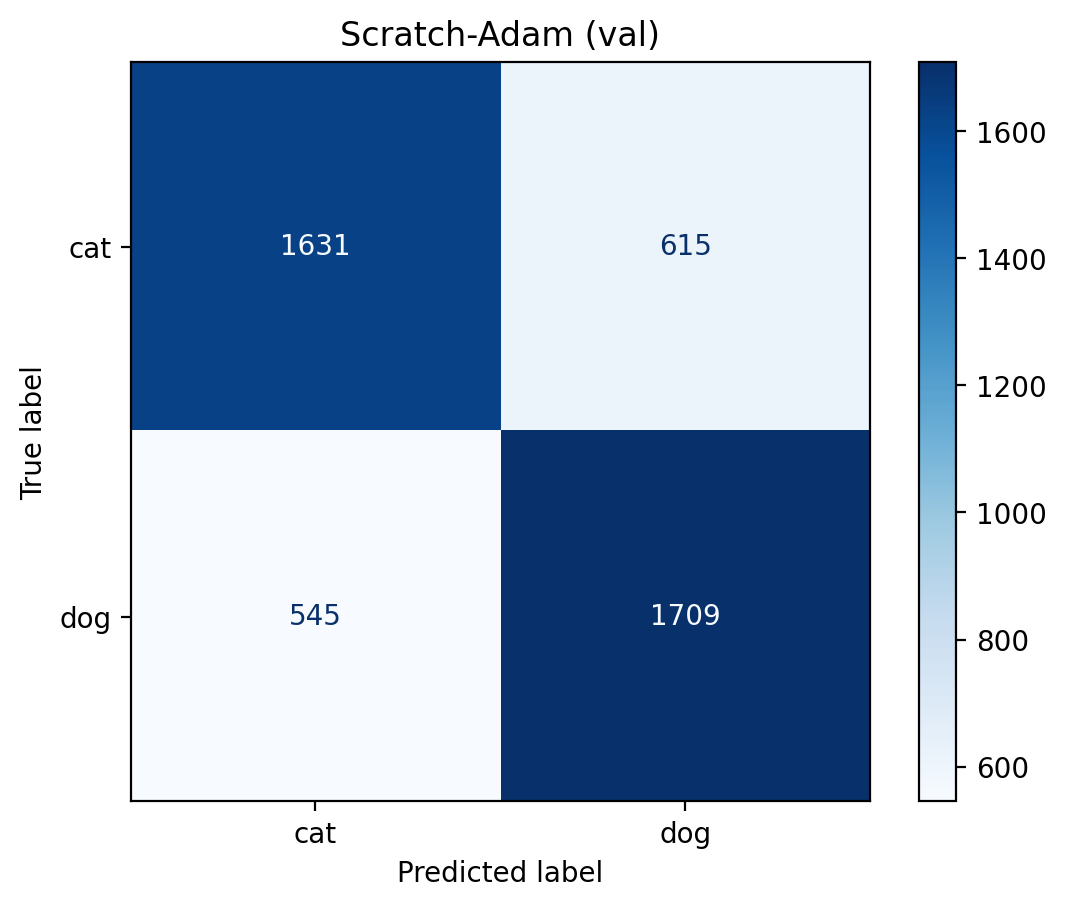

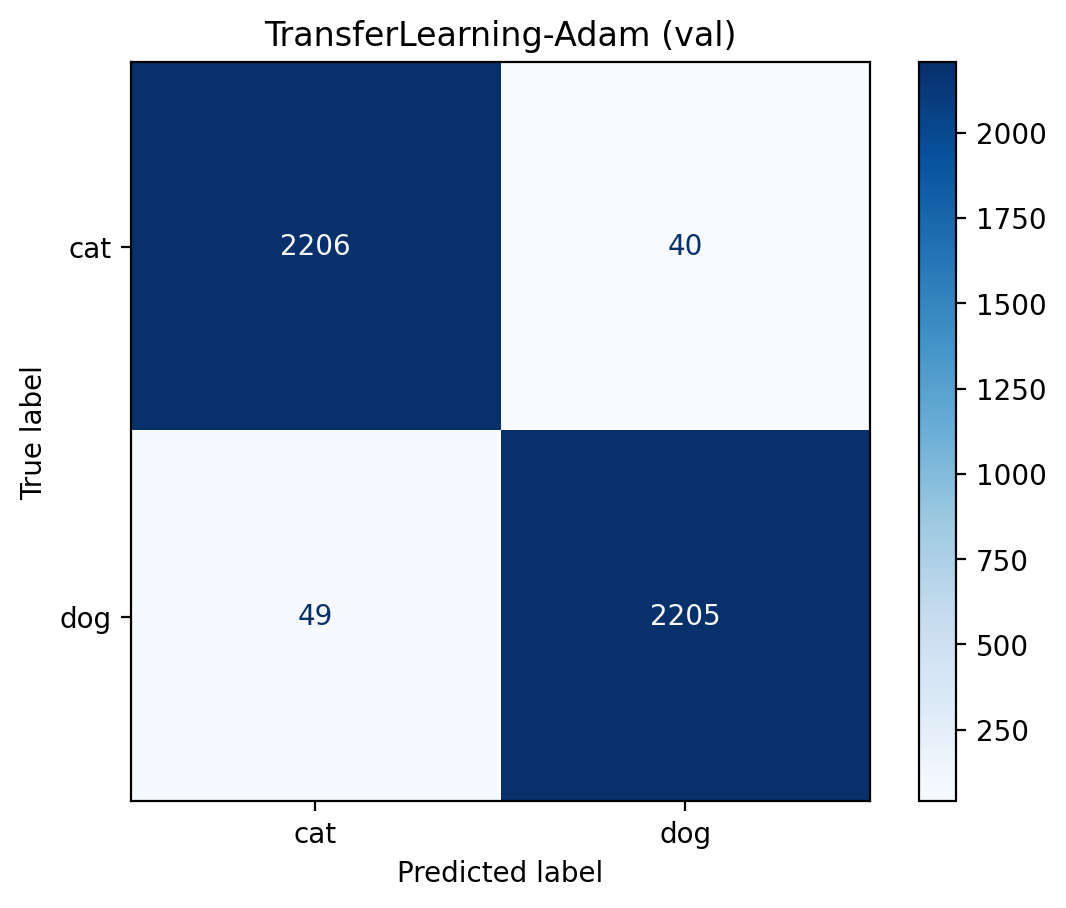

In [36]:
criterion = nn.CrossEntropyLoss()

def show_confusion(model, loader, device, class_names, title):
    _, _, _, _, preds, labels = evaluate(model, loader, criterion, device)
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.savefig(f"confusion_{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

show_confusion(model_scratch_best, val_loader, device, class_names,
                f"Scratch-{best_scratch_name} (val)")
show_confusion(model_tl_best, val_loader, device, class_names,
                f"TransferLearning-{best_tl_name} (val)")


## 10. Persistance du modèle : rechargement + évaluation finale sur le jeu de **test**

Conformément à la consigne, on **recharge** le meilleur checkpoint `.pth` de chaque expérience (comme si on redémarrait une session à zéro) puis on évalue **une seule fois** sur le jeu de test, jamais vu pendant l'entraînement ni la validation.

In [45]:
def load_and_evaluate(model_builder, checkpoint_path, test_loader, device, exp_name):
    model = model_builder().to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    test_loss, test_acc, test_prec, test_rec, preds, labels = evaluate(model, test_loader, criterion, device)
    print(f"[{exp_name}] Rechargé depuis '{checkpoint_path}' (époque {checkpoint['epoch']}, "
          f"val_acc à l'époque de sauvegarde = {checkpoint['val_acc']:.4f})")
    print(f"[{exp_name}] TEST -> loss {test_loss:.4f} | accuracy {test_acc:.4f} "
          f"| précision {test_prec:.4f} | recall {test_rec:.4f}")
    return {"exp_name": exp_name, "test_loss": test_loss, "test_acc": test_acc,
            "test_prec": test_prec, "test_rec": test_rec}


results = []
results.append(load_and_evaluate(
    lambda: SimpleCNN(num_classes=2), best_scratch_ckpt, test_loader, device,
    f"CNN from scratch ({best_scratch_name})"
))
results.append(load_and_evaluate(
    lambda: build_resnet_transfer(num_classes=2), best_tl_ckpt, test_loader, device,
    f"Transfer Learning ResNet18 ({best_tl_name})"
))

print("\n=== Résumé final (jeu de test) ===")
for r in results:
    print(f"{r['exp_name']:35s} | acc={r['test_acc']:.4f} | prec={r['test_prec']:.4f} "
          f"| recall={r['test_rec']:.4f} | loss={r['test_loss']:.4f}")

[CNN from scratch (Adam)] Rechargé depuis 'scratch_adam_best.pth' (époque 10, val_acc à l'époque de sauvegarde = 0.7422)
[CNN from scratch (Adam)] TEST -> loss 0.5294 | accuracy 0.7376 | précision 0.7346 | recall 0.7440
[Transfer Learning ResNet18 (Adam)] Rechargé depuis 'tl_adam_best.pth' (époque 4, val_acc à l'époque de sauvegarde = 0.9802)
[Transfer Learning ResNet18 (Adam)] TEST -> loss 0.0692 | accuracy 0.9752 | précision 0.9845 | recall 0.9656

=== Résumé final (jeu de test) ===
CNN from scratch (Adam)             | acc=0.7376 | prec=0.7346 | recall=0.7440 | loss=0.5294
Transfer Learning ResNet18 (Adam)   | acc=0.9752 | prec=0.9845 | recall=0.9656 | loss=0.0692


## 11. Analyse — Scratch vs Transfer Learning

*(À compléter par l'étudiant après exécution — 2 à 3 paragraphes attendus dans le README, en s'appuyant sur les chiffres et courbes obtenus ci-dessus.)*

**Convergence :** Décrire quelle approche converge le plus vite (nombre d'époques nécessaires pour atteindre un plateau de val_acc) et pourquoi (poids pré-entraînés vs initialisation aléatoire).

**Performance finale :** Comparer accuracy / précision / recall sur le jeu de test entre les deux approches. Expliquer l'écart en s'appuyant sur la taille du jeu de données disponible par rapport à la capacité du modèle.

**Robustesse / généralisation :** Comparer l'écart train vs validation (indicateur de sur-apprentissage) entre les deux modèles. Le CNN from scratch, avec beaucoup moins de données et de connaissances préalables, est généralement plus sujet au sur-apprentissage malgré Dropout/BatchNorm, alors que le transfer learning généralise mieux car les features de bas niveau (contours, textures) sont déjà robustes.

**Limites & pistes d'amélioration :** *(à compléter)* — ex. fine-tuning des dernières couches convolutionnelles du ResNet plutôt que gel total, augmentation de données plus poussée, recherche d'hyperparamètres plus systématique (grid/random search), plus d'époques avec early stopping, etc.


## 12. Checklist avant de rendre le devoir

- [ ] Les deux expériences (A: scratch, B: transfer learning) tournent de bout en bout sans erreur
- [ ] Dropout **et** BatchNorm utilisés et justifiés (section 6)
- [ ] Loss / Accuracy / Précision / Recall suivis à chaque époque, sur train **et** validation
- [ ] 2 optimiseurs testés pour chaque expérience (SGD et Adam)
- [ ] Scheduler de learning rate utilisé
- [ ] GPU vérifié et utilisé si disponible (section 3)
- [ ] Meilleur modèle sauvegardé en `.pth`, **rechargé**, puis évalué sur le test (section 10)
- [ ] Seed fixée pour la reproductibilité (section 2)
- [ ] Split train/val + data augmentation (section 4)
- [ ] Matrice de confusion (section 9)
- [ ] `data/`, `*.pt`, `*.pth`, `runs/`, `checkpoints/` ignorés par Git (voir `.gitignore` fourni)
- [ ] README.md rempli avec résultats, courbes et analyse (voir template fourni)
- [ ] Vidéo de 5–10 min explicative enregistrée
- [ ] Lien du dépôt envoyé à diallomous@gmail.com avant vendredi 25 septembre 23h00 (Africa/Dakar)
